# II.3 — Soluções das Atividades

Soluções de referência para as atividades do notebook [II.3](II.3_aplicacoes_do_calculo_multivariado.ipynb). Cada solução segue o exemplo indicado no enunciado.

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

## Atividade 1

Plano tangente e reta normal a $z = e^{-x^2-y^2}$ em $(0,0,1)$ (Exemplos 2 e 3).

Como $(0,0)$ é ponto de máximo de $f$, temos $f_x(0,0)=f_y(0,0)=0$: o plano tangente é horizontal, $z=1$, e a reta normal é vertical.

In [2]:
x, y = sp.symbols('x y')
f_exp = sp.exp(-x**2 - y**2)

a, b = 0, 0
fx_ab = sp.diff(f_exp, x).subs({x: a, y: b})
fy_ab = sp.diff(f_exp, y).subs({x: a, y: b})
f_ab  = f_exp.subs({x: a, y: b})

plano = f_ab + fx_ab*(x - a) + fy_ab*(y - b)
n = (int(fx_ab), int(fy_ab), -1)
print('plano tangente:  z =', sp.expand(plano))
print('vetor normal:    n =', n)
print('reta normal:     (x, y, z) = (0, 0, 1) + s*%s' % (n,))

plano tangente:  z = 1
vetor normal:    n = (0, 0, -1)
reta normal:     (x, y, z) = (0, 0, 1) + s*(0, 0, -1)


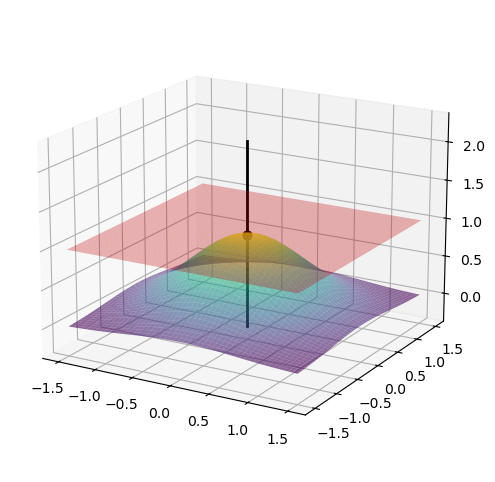

In [3]:
f = sp.lambdify([x, y], f_exp)
plano_fn = sp.lambdify([x, y], plano)

xi, yi = np.meshgrid(np.linspace(-1.5, 1.5, 50), np.linspace(-1.5, 1.5, 50))
s = np.linspace(-1.2, 1.2, 2)
lx, ly, lz = a + 0*s, b + 0*s, float(f_ab) - s

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(projection='3d')
ax.plot_surface(xi, yi, f(xi, yi), alpha=0.6, cmap='viridis')
ax.plot_surface(xi, yi, plano_fn(xi, yi) + 0*xi, alpha=0.3, color='red')
ax.plot(lx, ly, lz, color='black', lw=2)
ax.scatter([a], [b], [float(f_ab)], color='black', s=40)
ax.view_init(18, -60)
plt.show()

## Atividade 2

Aproximação linear de $f(x,y)=\ln(x-3y)$ em torno de $(7,2)$ para estimar $f(6{,}9;\,2{,}06)$ (Exemplo 4).

Em $(7,2)$: $x-3y=1$, logo $f=0$, $f_x=1/(x-3y)=1$ e $f_y=-3/(x-3y)=-3$, e $L(x,y)=x-3y-1$.

In [4]:
x, y = sp.symbols('x y')
f_exp = sp.log(x - 3*y)

a, b = 7, 2
fx_ab = sp.diff(f_exp, x).subs({x: a, y: b})
fy_ab = sp.diff(f_exp, y).subs({x: a, y: b})
f_ab  = f_exp.subs({x: a, y: b})

L = f_ab + fx_ab*(x - a) + fy_ab*(y - b)
print('L(x, y) =', sp.expand(L))

L_num = float(L.subs({x: 6.9, y: 2.06}))
exato = np.log(6.9 - 3*2.06)
print('L(6.9, 2.06)  =', L_num)
print('valor exato   =', exato)
print('erro absoluto =', abs(L_num - exato))

L(x, y) = x - 3*y - 1
L(6.9, 2.06)  = -0.27999999999999936
valor exato   = -0.32850406697203516
erro absoluto = 0.0485040669720358


O erro (~0,05) é maior que no Exemplo 4 porque $\ln$ varia rapidamente quando o argumento se aproxima de zero, e aqui $x-3y$ passou de $1$ para $0{,}72$ — uma variação relativa grande.

## Atividade 3

Erro máximo propagado em $V = xyz$ com $x=75$, $y=60$, $z=40$ (cm) e erro de $0{,}2$ cm em cada dimensão (Exemplo 5).

$dV = yz\,dx + xz\,dy + xy\,dz$; o erro máximo usa $|dx|=|dy|=|dz|=0{,}2$.

In [5]:
x, y, z = sp.symbols('x y z')
V_exp = x*y*z
vals = {x: 75, y: 60, z: 40}
d = 0.2

dV = sum(sp.Abs(sp.diff(V_exp, v).subs(vals))*d for v in (x, y, z))
print('Erro máximo estimado pela diferencial: dV =', float(dV), 'cm^3')

Erro máximo estimado pela diferencial: dV = 1980.0 cm^3


In [6]:
V = lambda x, y, z: x*y*z
rng = np.random.default_rng(0)
xs = 75 + rng.uniform(-d, d, 300000)
ys = 60 + rng.uniform(-d, d, 300000)
zs = 40 + rng.uniform(-d, d, 300000)

V0 = V(75, 60, 40)
print('V0 =', V0, 'cm^3')
print('Maior variação observada (amostragem):', np.abs(V(xs, ys, zs) - V0).max())

V0 = 180000 cm^3
Maior variação observada (amostragem): 1948.938921848603


## Atividade 4

Ponto sobre a interseção de $z=x^2+y^2$ com $y=2x$; $dx/dt=3$, achar $dz/dt$ em $x=1$ (Exemplo 7).

Sobre a curva, $z = x^2 + (2x)^2 = 5x^2$, então $dz/dt = 10x\,dx/dt$.

In [7]:
t = sp.symbols('t')
x_t = sp.Function('x')(t)
y_t = 2*x_t
z_t = x_t**2 + y_t**2

dzdt = sp.diff(z_t, t)
print('dz/dt =', dzdt)

val = dzdt.subs(sp.Derivative(x_t, t), 3).subs(x_t, 1)
print('em x = 1, dx/dt = 3:  dz/dt =', val)

dz/dt = 10*x(t)*Derivative(x(t), t)
em x = 1, dx/dt = 3:  dz/dt = 30


## Atividade 5

Escolha livre. Tomamos $f(x,y) = e^{x}\cos y$ em torno de $(a,b)=(0,0)$, onde $L(x,y) = 1 + x$. Plotamos o erro absoluto $|f-L|$ numa malha em torno da origem.

L(x, y) = x + 1


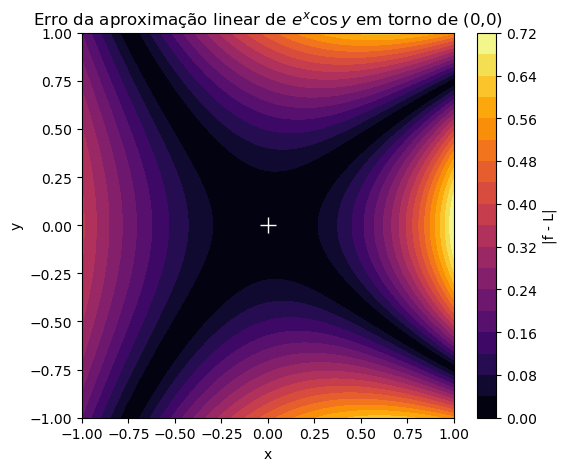

In [8]:
x, y = sp.symbols('x y')
f_exp = sp.exp(x)*sp.cos(y)
a, b = 0, 0

fx_ab = sp.diff(f_exp, x).subs({x: a, y: b})
fy_ab = sp.diff(f_exp, y).subs({x: a, y: b})
f_ab  = f_exp.subs({x: a, y: b})
L = f_ab + fx_ab*(x - a) + fy_ab*(y - b)
print('L(x, y) =', sp.expand(L))

f  = sp.lambdify([x, y], f_exp, 'numpy')
Lf = sp.lambdify([x, y], L, 'numpy')

xi, yi = np.meshgrid(np.linspace(-1, 1, 200), np.linspace(-1, 1, 200))
err = np.abs(f(xi, yi) - Lf(xi, yi))

fig, ax = plt.subplots(figsize=(6, 5))
c = ax.contourf(xi, yi, err, levels=20, cmap='inferno')
ax.plot(a, b, 'w+', ms=12)
fig.colorbar(c, label='|f - L|')
ax.set_title('Erro da aproximação linear de $e^x\\cos y$ em torno de (0,0)')
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.show()

O erro é praticamente nulo em $(0,0)$ e **cresce em todas as direções** conforme o ponto se afasta — aproximadamente como a distância ao quadrado, já que $L$ despreza justamente os termos de 2ª ordem de $f$.